<a href="https://colab.research.google.com/github/SFMoonLess/First_Repo/blob/main/%D0%A6%D0%A2%D0%9B%D0%A02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

   Фабрика_1  Фабрика_2  Разрез
0    1466.70     1056.0   320.0
1    1681.20     1135.0   322.0
2    1638.96     1106.0   320.0
3    1574.00     1171.0   318.0
4    1543.64     1176.0   320.0
      Фабрика_1  Фабрика_2  Разрез
8755    1812.30     1264.0  259.15
8756    1631.84     1205.0  268.53
8757    1818.64     1106.0  287.49
8758    1771.30     1121.0  268.06
8759    1819.84     1197.0  257.50
         Фабрика_1    Фабрика_2       Разрез
count  8760.000000  8760.000000  8760.000000
mean   1208.903541   954.777854   410.222599
std     455.678401   242.358431   243.915714
min       0.000000     0.000000    83.750000
25%     937.925000   844.750000   240.372500
50%    1334.710000   989.000000   333.000000
75%    1515.585000  1130.000000   509.250000
max    9452.840000  5772.000000  4407.310000


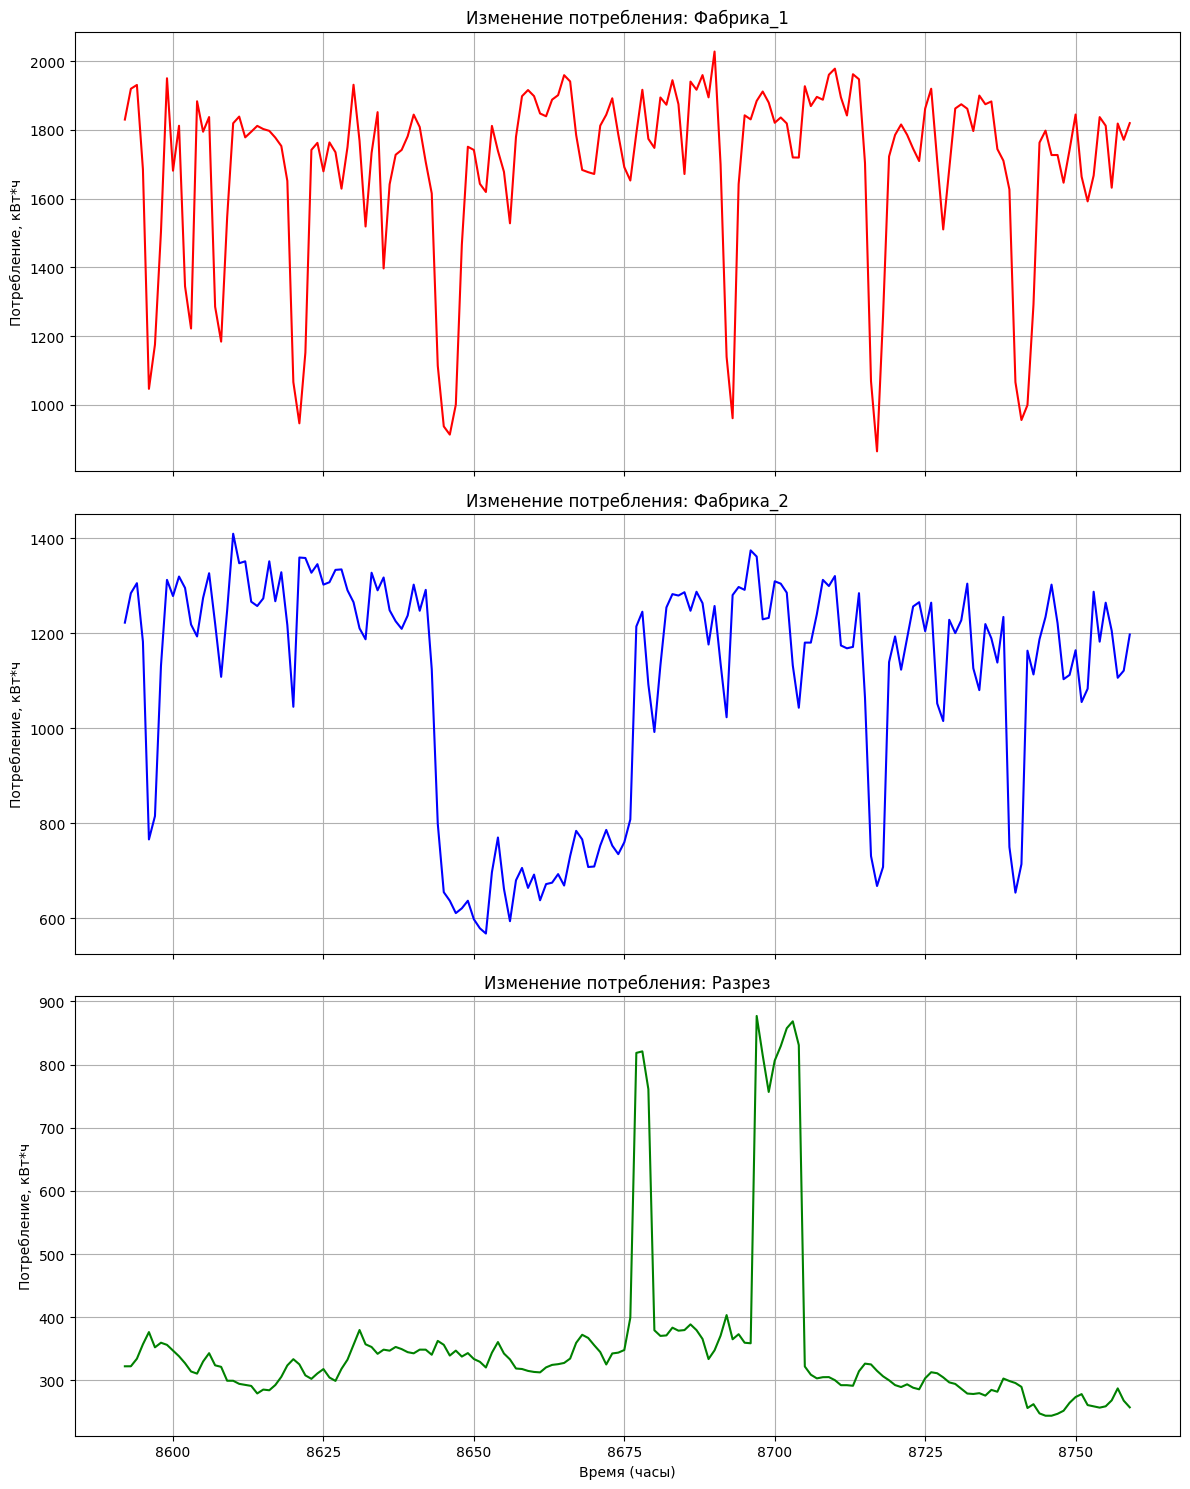

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from bokeh.plotting import figure, show
from bokeh.io import output_notebook

# 1. Подготовка и чтение данных
output_notebook()
# Путь к файлу согласно 10 варианту [4]
url = 'Электропотребление.xlsx'
df = pd.read_excel(url)

# 2. Просмотр структуры [3]
print(df.head())
print(df.tail())
print(df.describe())

# 3. Выделение данных за последнюю неделю (168 часов) [4]
last_week = df.tail(168)
enterprises = ['Фабрика_1', 'Фабрика_2', 'Разрез']

# 4. Статические графики (Matplotlib) [5, 6]
fig, axes = plt.subplots(3, 1, figsize=(12, 15), sharex=True)
colors = ['red', 'blue', 'green']

for i, col in enumerate(enterprises):
    axes[i].plot(last_week.index, last_week[col], color=colors[i])
    axes[i].set_ylabel('Потребление, кВт*ч')
    axes[i].set_title(f'Изменение потребления: {col}')
    axes[i].grid(True)

axes[-1].set_xlabel('Время (часы)')
plt.tight_layout()
plt.savefig('last_week_consumption.png') # Сохранение как изображение [3]
plt.show()

# 5. Интерактивный график (Bokeh) [3, 7]
p = figure(title="Интерактивный анализ потребления (последняя неделя)",
           x_axis_label='Часы', y_axis_label='кВт*ч', width=900, height=500)

for col, color in zip(enterprises, colors):
    p.line(last_week.index, last_week[col], legend_label=col, line_color=color, line_width=2)

p.legend.click_policy = "hide"
show(p)

# 6. Сохранение результатов в файлы [3, 8]
last_week.to_excel('result_option_10.xlsx', index=True)
last_week.to_csv('result_option_10.csv', index=True)